# Outlier Cleaning Practices
**Course:** Data Analysis and Indicators  
**Author:** Alan Jesús Hernández Soto
**Date:** February 2026

## Objective
Clean outliers from a dataset for a fictional real-estate company named 'Elite Properties' using the variables *area* and *price*.

## Datasets
- **Source:** Class material
- **Files:** houses_data_outliers.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore

pd.set_option('display.float_format', '{:,.2f}'.format)

houses = pd.read_csv('houses_data_outliers.csv')

In [2]:
houses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2639 entries, 0 to 2638
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      2639 non-null   int64  
 1   Area    2639 non-null   object 
 2   Precio  2639 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 62.0+ KB


In [3]:
houses['Precio'].describe()

count       2,639.00
mean    1,357,028.23
std     1,098,868.33
min       145,000.00
25%       655,000.00
50%       957,000.00
75%     1,650,000.00
max     8,000,000.00
Name: Precio, dtype: float64

Analyze house prices by area.

In [4]:
price_by_area = houses.groupby('Area').agg(
    Houses=('id', 'count'),
    Price_Median=('Precio', 'median'),
    Price_Average=('Precio', 'mean'),
    Price_Maximum=('Precio', 'max'),
    Price_Minimum=('Precio', 'min')
).reset_index()

price_by_area

,Area,Houses,Price_Median,Price_Average,Price_Maximum,Price_Minimum
0,Boroondara,625,"1,800,000.00","2,137,082.76","8,000,000.00","275,000.00"
1,Darebin,482,"885,000.00","1,158,626.84","3,631,504.34","216,000.00"
2,Melbourne,279,"800,000.00","1,230,859.15","4,525,000.00","275,000.00"
3,Moonee Valley,553,"953,000.00","1,173,741.71","3,798,510.66","222,000.00"
4,Moreland,700,"792,500.00","992,248.23","3,196,082.21","145,000.00"


**Histogram**

When analyzing the histogram, we can see that higher prices occur less frequently.

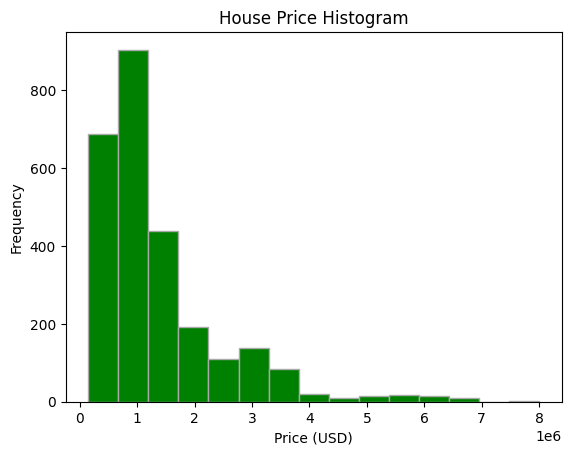

In [5]:
plt.hist(houses['Precio'], bins=15, edgecolor='darkgray', color='green')
# Add titles and labels
plt.title('House Price Histogram')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.show()

**Box Plot**

The points represent outlier data points.

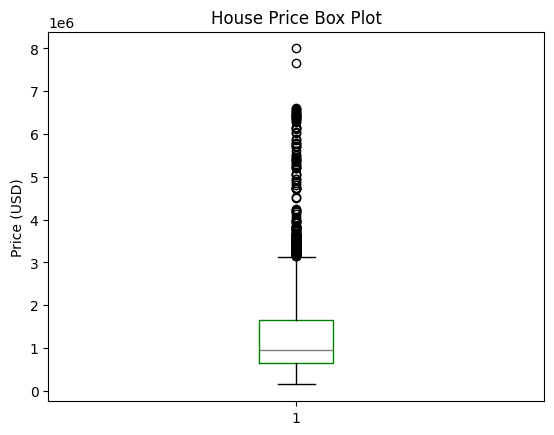

In [6]:
plt.boxplot(houses['Precio'], boxprops=dict(color='green'), medianprops=dict(color='gray'))
# Add titles and labels
plt.title('House Price Box Plot')
plt.ylabel('Price (USD)')
plt.show()

**Z-Score**

Outliers are identified using the *z-score* method.

In [7]:
# Calculate the z-score for each point and its absolute value
z_scores = zscore(houses['Precio'])
abs_z_scores = np.abs(z_scores)

# Select outliers with a threshold of 3
houses['outlier_zscore'] = (abs_z_scores > 3) * 1
houses.head()

,id,Area,Precio,outlier_zscore
0,1,Moonee Valley,"840,000.00",0
1,2,Moonee Valley,"730,000.00",0
2,3,Moonee Valley,"770,000.00",0
3,4,Moonee Valley,"3,396,876.76",0
4,5,Moonee Valley,"700,000.00",0


Outliers by area

In [8]:
zscore_group = houses.groupby('Area').agg(
    Houses=('id', 'count'),
    Outliers=('outlier_zscore', 'sum')
).reset_index()

zscore_group['Outlier_Ratio'] = zscore_group['Outliers'] / zscore_group['Houses']

zscore_group


,Area,Houses,Outliers,Outlier_Ratio
0,Boroondara,625,64,0.10
1,Darebin,482,0,0.00
2,Melbourne,279,0,0.00
3,Moonee Valley,553,0,0.00
4,Moreland,700,0,0.00


Average price for non-outliers and outliers.

In [9]:
houses.groupby(['Area', 'outlier_zscore']).agg(
    Houses=('id', 'count'),
    Average_Price=('Precio', 'mean')
).reset_index()

,Area,outlier_zscore,Houses,Average_Price
0,Boroondara,0,561,"1,721,240.00"
1,Boroondara,1,64,"5,782,204.47"
2,Darebin,0,482,"1,158,626.84"
3,Melbourne,0,279,"1,230,859.15"
4,Moonee Valley,0,553,"1,173,741.71"
5,Moreland,0,700,"992,248.23"


**Interquartile Range (IQR)**

Outliers are identified using the *IQR* method.

In [10]:
# Calculate percentiles
q75 = houses['Precio'].quantile(0.75)
q25 = houses['Precio'].quantile(0.25)

# Obtain the IQR
iqr = q75 - q25

# thresholds
upper = q75 + (1.5 * iqr)
lower = q25 - (1.5 * iqr)

houses['outlier_iqr'] = ((houses['Precio'] < lower) | (houses['Precio'] > upper)) * 1
houses.head()


,id,Area,Precio,outlier_zscore,outlier_iqr
0,1,Moonee Valley,"840,000.00",0,0
1,2,Moonee Valley,"730,000.00",0,0
2,3,Moonee Valley,"770,000.00",0,0
3,4,Moonee Valley,"3,396,876.76",0,1
4,5,Moonee Valley,"700,000.00",0,0


Outliers by area

In [11]:
iqr_group = houses.groupby('Area').agg(
    Houses=('id', 'count'),
    Outliers=('outlier_iqr', 'sum'),
).reset_index()

iqr_group['Outlier_Ratio'] = iqr_group['Outliers'] / iqr_group['Houses']

iqr_group

,Area,Houses,Outliers,Outlier_Ratio
0,Boroondara,625,104,0.17
1,Darebin,482,33,0.07
2,Melbourne,279,32,0.11
3,Moonee Valley,553,32,0.06
4,Moreland,700,7,0.01


Average price for non-outliers and outliers.

In [12]:
houses.groupby(['Area', 'outlier_iqr']).agg(
    Houses=('id', 'count'),
    Average_Price=('Precio', 'mean')
).reset_index()

,Area,outlier_iqr,Houses,Average_Price
0,Boroondara,0,521,"1,582,999.31"
1,Boroondara,1,104,"4,912,827.75"
2,Darebin,0,449,"994,879.10"
3,Darebin,1,33,"3,386,588.55"
4,Melbourne,0,247,"905,122.90"
5,Melbourne,1,32,"3,745,135.81"
6,Moonee Valley,0,521,"1,033,747.38"
7,Moonee Valley,1,32,"3,453,024.41"
8,Moreland,0,693,"970,233.94"
9,Moreland,1,7,"3,171,663.14"


**Interquartile Range (IQR)**

**Student Exercises:**

Identify the **extreme values** using the IQR method.

In [13]:
# Calculate percentiles
q75 = houses['Precio'].quantile(0.75)
q25 = houses['Precio'].quantile(0.25)

# Obtain the IQR
iqr = q75 - q25

# thresholds (3 extreme values)
upper = q75 + (3 * iqr)
lower = q25 - (3 * iqr)

houses['extreme_iqr'] = ((houses['Precio'] < lower) | (houses['Precio'] > upper)) * 1
houses.head()

,id,Area,Precio,outlier_zscore,outlier_iqr,extreme_iqr
0,1,Moonee Valley,"840,000.00",0,0,0
1,2,Moonee Valley,"730,000.00",0,0,0
2,3,Moonee Valley,"770,000.00",0,0,0
3,4,Moonee Valley,"3,396,876.76",0,1,0
4,5,Moonee Valley,"700,000.00",0,0,0


Extreme values by area

In [14]:
iqr_group = houses.groupby('Area').agg(
    Houses=('id', 'count'),
    Extreme=('extreme_iqr', 'sum'),
).reset_index()

iqr_group['Extreme_Ratio'] = iqr_group['Extreme'] / iqr_group['Houses']

iqr_group

,Area,Houses,Extreme,Extreme_Ratio
0,Boroondara,625,64,0.10
1,Darebin,482,0,0.00
2,Melbourne,279,0,0.00
3,Moonee Valley,553,0,0.00
4,Moreland,700,0,0.00


Average price for non-extreme and extreme values.

In [15]:
houses.groupby(['Area', 'extreme_iqr']).agg(
    Houses=('id', 'count'),
    Average_Price=('Precio', 'mean')
).reset_index()

,Area,extreme_iqr,Houses,Average_Price
0,Boroondara,0,561,"1,721,240.00"
1,Boroondara,1,64,"5,782,204.47"
2,Darebin,0,482,"1,158,626.84"
3,Melbourne,0,279,"1,230,859.15"
4,Moonee Valley,0,553,"1,173,741.71"
5,Moreland,0,700,"992,248.23"
